# 🧪 DL Project Template — A PyTorch Image Classifier You Can Trust

> **What this is:** a copy-and-fill starter notebook for a **new** PyTorch image-classification project. Every decision is a `# TODO(you):` marker with a sensible default. As shipped, it trains a real model on a small subset of real satellite images in a few minutes, so you can watch every step work before you change anything.

| | |
|---|---|
| **Difficulty** | 🟡 Intermediate |
| **Time** | ~1 minute to run on an Apple Silicon laptop (plus a 94 MB download once; several times slower on a CPU), ~40 minutes to read; 1–3 days to adapt to a real project |
| **Prerequisites** | [End-to-End DL Project](../13_Capstone_Projects/02_End_to_End_DL_Project.ipynb) (the full worked example behind this template) · [PyTorch](../04_Deep_Learning/02_PyTorch.ipynb) |
| **Tested with** | Python 3.12 · torch 2.14 · torchvision 0.29 · scikit-learn 1.9 · pandas 3.0 · Apple Silicon MPS (CUDA and CPU paths use the same code) |
| **Interview relevance** | ⭐⭐⭐ High — "walk me through your training loop", mixed precision, early stopping and checkpoints, calibration, error analysis, exporting a model for serving |

**Example data:** [EuroSAT RGB](https://github.com/phelber/EuroSAT) — 27,000 labelled 64×64 satellite tiles in 10 land-use classes (MIT license). The template uses **400 tiles per class** so training takes about a minute; set `max_per_class=None` for the full dataset.

## 🗺️ How to Use This Template

1. **Copy it** into your project folder and give it a real name, e.g. `my_project/01_defect_classifier.ipynb`. Keep the original untouched.
2. **Run it once unchanged** (*Kernel → Restart & Run All*). Now you know every cell works on your machine and roughly how fast your device trains.
3. **Fill in the TODOs top to bottom.** Search for `TODO(you)`. Most decisions live in **Step 1 (`CONFIG`)**, **Step 3 (your data)**, and **Step 4 (augmentations that keep labels true)**. Re-run from the top after each change.
4. **Delete what you don't need:**

| Delete… | …when |
|---|---|
| the "Example data" paragraph and EuroSAT notes in markdown cells | always, once your data is in |
| the `download_example` branch in Step 3 | your images are already on disk |
| Step 8's resume *proof* (keep the `resume_from=` argument!) | after you trust the checkpoint code once |
| the ONNX part of Step 11 | you serve with PyTorch (`torch.export` files) only |

5. **Tick the ✅ Checklist** at the end before anyone uses the model.

**Guardrails already built in** (the mistakes the capstone project fixed):

| Classic mistake | Where this template prevents it |
|---|---|
| a different random split every run | Step 5: stratified splits **saved to CSV** with hashes, reused when the data is unchanged |
| preprocessing drifts between training and serving | Step 6: resize + normalization live **inside the model**; one eval transform function everywhere |
| "mixed precision is always faster" | Step 7: speed is **measured on your device** and AMP is used only if it helps |
| picking the last epoch, losing a crashed run | Step 7–8: early stopping on validation, `best.pt` + `last.pt`, and a proven resume |
| test set used for decisions | Steps 9–10: test scored **once**; error analysis and temperature use validation |
| export fails on GPU/MPS: example tensor on the wrong device | Step 11: the example input is created **on the model's device**, and the error is shown honestly |

The full worked example with a package, FastAPI upload service, Docker, and CI is the [End-to-End DL Project](../13_Capstone_Projects/02_End_to_End_DL_Project.ipynb).

## 1. Setup and the `CONFIG` Cell 🟢

The first cell imports everything and prints versions. The second cell is **the one place for project decisions**: a single dictionary is easy to review, gets saved into the checkpoint and metadata, and later becomes a YAML file or command-line flags for a training script.

In [1]:
# %pip install -q "torch>=2.14,<3" "torchvision>=0.29,<1" "scikit-learn>=1.9,<2" "pandas>=3.0,<4" pillow matplotlib
# Optional ONNX export: %pip install -q onnx onnxscript onnxruntime

import copy
import gc
import hashlib
import importlib.metadata as md
import importlib.util
import json
import math
import os
import platform
import random
import time
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import torchvision
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, f1_score
from sklearn.model_selection import train_test_split
from torch import nn
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import ImageFolder
from torchvision.models import ResNet18_Weights, resnet18
from torchvision.transforms import v2

NOTEBOOK_DIR = Path.cwd()
NOTEBOOK_START = time.perf_counter()
print(f"Python {platform.python_version()} | " + " | ".join(f"{p} {md.version(p)}" for p in ["torch", "torchvision", "scikit-learn", "pandas", "numpy"]))


def rel(text):
    """Show paths relative to this notebook and never print the local home folder."""
    text = str(text).replace(str(NOTEBOOK_DIR) + os.sep, "").replace(str(NOTEBOOK_DIR), ".")
    return text.replace(str(Path.home()), "~")


def file_sha256(path) -> str:
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(1 << 20), b""):
            digest.update(chunk)
    return digest.hexdigest()

Python 3.12.11 | torch 2.14.0 | torchvision 0.29.0 | scikit-learn 1.9.1 | pandas 3.0.5 | numpy 2.5.3


In [2]:
CONFIG = {
    # ── project ────────────────────────────────────────────────────────────────
    "project_name": "eurosat_landuse",           # TODO(you): short snake_case name for files and metadata
    "model_version": "0.1.0",                    # TODO(you): bump per release; a weights fingerprint is appended
    "output_dir": Path("_outputs") / "dl_template",   # TODO(you): keep it git-ignored (splits, checkpoints, artifacts)
    # ── data (Steps 3–5) ───────────────────────────────────────────────────────
    "data_source": "image_folder",               # TODO(you): "image_folder" (one sub-folder per class) | "tensors" (Step 3 function)
    "image_folder": Path("_outputs") / "data" / "eurosat" / "2750",   # TODO(you): your folder, e.g. Path("data/images")
    "download_example": True,                    # downloads EuroSAT (94 MB) when image_folder is missing — set False for your data
    "max_per_class": 400,                        # TODO(you): None = use everything; small numbers for fast iteration
    "image_size": 64,                            # TODO(you): images are resized to this square size by the data transforms
    "val_size": 0.15, "test_size": 0.15,
    "batch_size": 64, "num_workers": 0,          # TODO(you): workers > 0 needs the Dataset class in a .py file on macOS/Windows
    # ── model (Step 6) ────────────────────────────────────────────────────────
    "model_name": "resnet18",                    # TODO(you): "small_cnn" (from scratch) | "resnet18" (pretrained backbone + new head)
    "pretrained": True,
    "model_input_size": 112,                     # pretrained CNNs like bigger inputs: upsampled INSIDE the model
    # ── training (Step 7) ─────────────────────────────────────────────────────
    "epochs": 8,                                 # TODO(you): an upper bound — early stopping usually ends sooner
    "lr": 1e-3, "body_lr_factor": 0.1,           # pretrained layers learn 10× slower than the new head
    "weight_decay": 1e-4, "warmup_fraction": 0.1, "min_lr_ratio": 0.01,
    "grad_clip_norm": 1.0, "label_smoothing": 0.0,
    "patience": 3,                               # early stopping: epochs without validation-loss improvement
    "mixed_precision": "auto",                   # TODO(you): "auto" (measure on this device) | "on" | "off"
    "seed": 42,
}
OUT = CONFIG["output_dir"]
for sub in ("splits", "checkpoints", "artifacts"):
    (OUT / sub).mkdir(parents=True, exist_ok=True)
assert CONFIG["data_source"] in {"image_folder", "tensors"} and CONFIG["model_name"] in {"small_cnn", "resnet18"}
print(json.dumps({k: str(v) for k, v in CONFIG.items()}, indent=1))

{
 "project_name": "eurosat_landuse",
 "model_version": "0.1.0",
 "output_dir": "_outputs/dl_template",
 "data_source": "image_folder",
 "image_folder": "_outputs/data/eurosat/2750",
 "download_example": "True",
 "max_per_class": "400",
 "image_size": "64",
 "val_size": "0.15",
 "test_size": "0.15",
 "batch_size": "64",
 "num_workers": "0",
 "model_name": "resnet18",
 "pretrained": "True",
 "model_input_size": "112",
 "epochs": "8",
 "lr": "0.001",
 "body_lr_factor": "0.1",
 "weight_decay": "0.0001",
 "warmup_fraction": "0.1",
 "min_lr_ratio": "0.01",
 "grad_clip_norm": "1.0",
 "label_smoothing": "0.0",
 "patience": "3",
 "mixed_precision": "auto",
 "seed": "42"
}


## 2. Device Selection and Reproducibility 🟢

**Device order:** NVIDIA GPU (`cuda`) → Apple GPU (`mps`) → `cpu`. The same code runs on all three.

**Reproducibility** means the same code and data give the same model. We seed Python, NumPy, and PyTorch. On CPU that usually gives identical runs; on GPUs some fast kernels are not bit-exact, so expect tiny differences (for strict determinism on CUDA see `torch.use_deterministic_algorithms`, at a speed cost).

In [3]:
def pick_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)                      # seeds CPU, CUDA, and MPS generators
    torch.backends.cudnn.benchmark = False       # benchmark mode picks kernels non-deterministically


def free_memory() -> None:
    gc.collect()
    if DEVICE.type == "mps":
        torch.mps.empty_cache()
    elif DEVICE.type == "cuda":
        torch.cuda.empty_cache()


DEVICE = pick_device()
seed_everything(CONFIG["seed"])
print(f"device: {DEVICE}" + (" — ⚠️ no GPU: lower epochs and max_per_class, or use small_cnn" if DEVICE.type == "cpu" else ""))

device: mps


## 3. Dataset Adapter 🟢

The adapter turns *your* storage into one table with a row per example: an identifier (`path` for files, `index` for tensors), the class name `label`, and its integer `label_idx`. Everything later only reads that table plus one function, `load_raw(row)`, that returns a PIL image.

- **`image_folder`**: the most common layout, `root/<class name>/<image file>`. `torchvision.datasets.ImageFolder` scans it; classes are sorted alphabetically.
- **`tensors`**: images already in memory (from `.npy`, HDF5, a database). Fill in `load_my_tensors()`.

4,000 examples · 10 classes · scanned in 0.4 s
label
AnnualCrop              400
Forest                  400
HerbaceousVegetation    400
Highway                 400
Industrial              400
Pasture                 400
PermanentCrop           400
Residential             400
River                   400
SeaLake                 400
largest/smallest class ratio 1.0 | majority-class accuracy 10.0% (the number to beat)


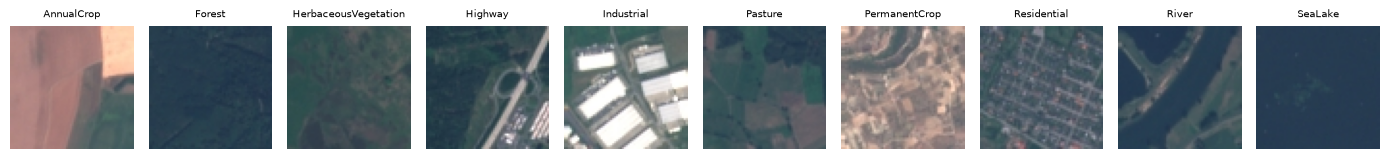

In [4]:
def load_my_tensors():
    """TODO(you): return (images uint8 tensor N×C×H×W, labels int64 tensor N, class_names list[str])."""
    raise NotImplementedError("Implement load_my_tensors(), e.g. data = np.load('data.npz'); "
                              "return torch.from_numpy(data['x']), torch.from_numpy(data['y']), ['cat', 'dog']")


TENSORS = None


def load_samples(config: dict) -> tuple[pd.DataFrame, list[str]]:
    global TENSORS
    if config["data_source"] == "image_folder":
        root = Path(config["image_folder"])
        if not root.exists() and config["download_example"]:
            from torchvision.datasets import EuroSAT
            EuroSAT(root=root.parent.parent, download=True)                  # example data only: creates root/../../eurosat/2750
        folder = ImageFolder(root)
        samples = pd.DataFrame({"path": [Path(p).relative_to(root).as_posix() for p, _ in folder.samples],
                                "label_idx": [i for _, i in folder.samples]})
        classes = folder.classes
    else:
        images, labels, classes = load_my_tensors()
        assert images.dtype == torch.uint8 and images.ndim == 4, "images must be uint8 N×C×H×W"
        TENSORS = images
        samples = pd.DataFrame({"index": np.arange(len(images)), "label_idx": labels.numpy()})
    samples["label"] = [classes[i] for i in samples["label_idx"]]
    if config["max_per_class"]:
        samples = samples.sample(frac=1.0, random_state=config["seed"]).groupby("label_idx").head(config["max_per_class"])
    key = "path" if "path" in samples else "index"
    return samples.sort_values(key).reset_index(drop=True), list(classes)


def load_raw(row) -> Image.Image:
    """One raw example as an RGB PIL image — the ONLY place that reads data. TODO(you): grayscale? use .convert('L') and 1 channel."""
    if CONFIG["data_source"] == "image_folder":
        with Image.open(Path(CONFIG["image_folder"]) / row["path"]) as image:
            return image.convert("RGB")
    return v2.functional.to_pil_image(TENSORS[int(row["index"])])


start = time.perf_counter()
samples, CLASSES = load_samples(CONFIG)
NUM_CLASSES = len(CLASSES)
counts = samples["label"].value_counts().reindex(CLASSES)
print(f"{len(samples):,} examples · {NUM_CLASSES} classes · scanned in {time.perf_counter() - start:.1f} s")
print(counts.to_string())
print(f"largest/smallest class ratio {counts.max() / counts.min():.1f} | majority-class accuracy {counts.max() / counts.sum():.1%} (the number to beat)")

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(1.4 * NUM_CLASSES, 1.9))
for ax, name in zip(np.atleast_1d(axes), CLASSES):
    ax.imshow(load_raw(samples[samples["label"] == name].iloc[0]))
    ax.set_title(name, fontsize=7)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Transforms and Augmentation 🟢

**Transforms** turn a raw image into the tensor the model eats. **Augmentation** = random changes that keep the label true, so the model learns the object, not the exact pixels. Only the training split is augmented; validation, test, and serving use the deterministic `make_eval_transform`, the **same function** the inference code uses later.

Choose augmentations your domain allows. Satellite tiles have no "up", so flips and 90° rotations are safe. For text, digits, or medical scans with a fixed orientation, a flip can **change the label** (a mirrored "b" is a "d").

Normalization (subtracting the ImageNet mean) is **not** here: it lives inside the model (Step 6) so the exported model accepts plain `[0, 1]` images.

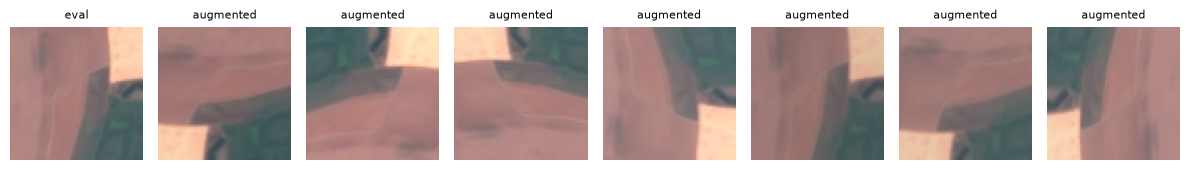

eval tensor: (3, 64, 64) torch.float32 range [0.25, 1.00]


In [5]:
SIZE = CONFIG["image_size"]


def make_eval_transform(size: int = SIZE) -> v2.Compose:
    return v2.Compose([v2.ToImage(), v2.Resize((size, size), antialias=True), v2.ToDtype(torch.float32, scale=True)])


train_transform = v2.Compose([
    v2.ToImage(),
    v2.RandomResizedCrop((SIZE, SIZE), scale=(0.8, 1.0), antialias=True),    # TODO(you): zoom range that keeps the object visible
    v2.RandomHorizontalFlip(),                                                # TODO(you): remove flips if orientation carries meaning
    v2.RandomVerticalFlip(),
    v2.RandomChoice([v2.RandomRotation((angle, angle)) for angle in (0, 90, 180, 270)]),
    v2.ColorJitter(brightness=0.1, contrast=0.1),                             # small lighting changes; colour itself is signal here
    v2.ToDtype(torch.float32, scale=True),
])
eval_transform = make_eval_transform()

example = load_raw(samples.iloc[0])
fig, axes = plt.subplots(1, 8, figsize=(12, 1.9))
axes[0].imshow(eval_transform(example).permute(1, 2, 0))
axes[0].set_title("eval", fontsize=8)
for ax in axes[1:]:
    ax.imshow(train_transform(example).permute(1, 2, 0).clamp(0, 1))
    ax.set_title("augmented", fontsize=8)
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()
print("eval tensor:", tuple(eval_transform(example).shape), eval_transform(example).dtype, f"range [{eval_transform(example).min():.2f}, {eval_transform(example).max():.2f}]")

## 5. Saved Stratified Splits and DataLoaders 🟢

We split **once**, stratified by class (every split keeps the class mix), and **save the lists to CSV** with SHA-256 hashes. The next run reuses them as long as the sample list and split settings are unchanged, so every experiment is compared on exactly the same validation images, and the metadata can prove which data a model saw.

⚠️ **Group leakage:** if several images show the same object, patient, or location, a random split puts near-duplicates in train and test and inflates scores. Then split by that group instead (`GroupShuffleSplit` on a group column).

A `Dataset` returns one `(image_tensor, label)`; a `DataLoader` batches and shuffles them. The training loader gets its own seeded `torch.Generator`, so the shuffle order is reproducible and can be saved in checkpoints.

In [6]:
SPLIT_DIR = OUT / "splits"
key_column = "path" if "path" in samples else "index"
signature = hashlib.sha256(json.dumps({"ids": samples[key_column].astype(str).tolist(), "labels": samples["label_idx"].tolist(),
                                       "seed": CONFIG["seed"], "val": CONFIG["val_size"], "test": CONFIG["test_size"]}).encode()).hexdigest()
signature_file = SPLIT_DIR / "signature.txt"
if signature_file.exists() and signature_file.read_text() == signature:
    splits = {name: pd.read_csv(SPLIT_DIR / f"{name}.csv") for name in ("train", "validation", "test")}
    print("♻️ reusing saved splits (same samples and settings)")
else:
    train_val, test = train_test_split(samples, test_size=CONFIG["test_size"], stratify=samples["label_idx"], random_state=CONFIG["seed"])
    train, val = train_test_split(train_val, test_size=CONFIG["val_size"] / (1 - CONFIG["test_size"]), stratify=train_val["label_idx"], random_state=CONFIG["seed"])
    splits = {"train": train, "validation": val, "test": test}
    for name, frame in splits.items():
        frame.sort_values(key_column).to_csv(SPLIT_DIR / f"{name}.csv", index=False)
    signature_file.write_text(signature)
    splits = {name: pd.read_csv(SPLIT_DIR / f"{name}.csv") for name in splits}
    print("💾 created and saved new stratified splits")
SPLIT_HASHES = {name: file_sha256(SPLIT_DIR / f"{name}.csv") for name in splits}
ids = {name: set(frame[key_column]) for name, frame in splits.items()}
assert not (ids["train"] & ids["validation"] or ids["train"] & ids["test"] or ids["validation"] & ids["test"])
print(pd.DataFrame({name: {"examples": len(frame), "smallest class share": frame["label_idx"].value_counts(normalize=True).min(),
                           "sha256": SPLIT_HASHES[name][:12] + "…"} for name, frame in splits.items()}).T.to_string())


class ImageDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, transform):
        self.frame, self.transform = frame.reset_index(drop=True), transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, i):
        row = self.frame.iloc[i]
        return self.transform(load_raw(row)), int(row["label_idx"])


def make_loader(frame, transform, shuffle, batch_size=CONFIG["batch_size"], seed=CONFIG["seed"]):
    return DataLoader(ImageDataset(frame, transform), batch_size=batch_size, shuffle=shuffle,
                      generator=torch.Generator().manual_seed(seed) if shuffle else None,
                      num_workers=CONFIG["num_workers"], pin_memory=DEVICE.type == "cuda", persistent_workers=CONFIG["num_workers"] > 0)


train_loader = make_loader(splits["train"], train_transform, shuffle=True)
val_loader = make_loader(splits["validation"], eval_transform, shuffle=False)
test_loader = make_loader(splits["test"], eval_transform, shuffle=False)          # 🔒 locked until Step 9
xb, yb = next(iter(train_loader))
start = time.perf_counter()
n_batches = sum(1 for _ in val_loader)
print(f"batch {tuple(xb.shape)} {xb.dtype} · labels {tuple(yb.shape)} · {len(train_loader)} training batches/epoch · "
      f"one pass over validation ({n_batches} batches) takes {time.perf_counter() - start:.1f} s of loading")

♻️ reusing saved splits (same samples and settings)
           examples smallest class share         sha256
train          2800                  0.1  85505fc03806…
validation      600                  0.1  50e6f73e5daf…
test            600                  0.1  110943186f6a…
batch (64, 3, 64, 64) torch.float32 · labels (64,) · 44 training batches/epoch · one pass over validation (10 batches) takes 0.1 s of loading


> 💡 **Interview angle:** "Your GPU sits at 30% utilization. Why?" — the input pipeline is the bottleneck (JPEG decoding, Python transforms, too few workers). Measure loading time alone (as above), then add workers, cache decoded images, or move augmentation to the GPU.

## 6. Model Factory 🟢

`build_model` returns either a **small CNN trained from scratch** (fast, a good baseline and a pipeline sanity check) or a **pretrained ResNet-18 with a new head** (transfer learning: reuse edge and texture detectors learned on 1.28 million ImageNet photos; replace only the last layer so it predicts *your* classes).

Both are wrapped in `ImageModel`, which **resizes and normalizes inside `forward`**. The exported model then takes plain `[0, 1]` RGB images at `image_size`, and no preprocessing constants can go missing between training and serving.

In [7]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes: int, in_channels: int = 3, width: int = 32):
        super().__init__()
        layers, channels = [], in_channels
        for out in (width, width * 2, width * 4):
            layers += [nn.Conv2d(channels, out, 3, padding=1, bias=False), nn.BatchNorm2d(out), nn.ReLU(inplace=True), nn.MaxPool2d(2)]
            channels = out
        self.features, self.pool, self.fc = nn.Sequential(*layers), nn.AdaptiveAvgPool2d(1), nn.Linear(channels, num_classes)

    def forward(self, x):
        return self.fc(torch.flatten(self.pool(self.features(x)), 1))


class ImageModel(nn.Module):
    """Resize + normalize inside the model; `net.fc` is the task-specific head."""

    def __init__(self, net: nn.Module, image_size: int, input_size: int, mean, std):
        super().__init__()
        self.net, self.input_size, self.resize = net, input_size, input_size != image_size
        self.register_buffer("mean", torch.tensor(mean).view(1, -1, 1, 1))
        self.register_buffer("std", torch.tensor(std).view(1, -1, 1, 1))

    def forward(self, x):
        if self.resize:
            x = F.interpolate(x, size=(self.input_size, self.input_size), mode="bilinear", align_corners=False)
        return self.net((x - self.mean) / self.std)

    def head_parameters(self):
        return list(self.net.fc.parameters())

    def body_parameters(self):
        head = {id(p) for p in self.head_parameters()}
        return [p for p in self.parameters() if id(p) not in head]


def build_model(name: str, num_classes: int, pretrained: bool = True) -> ImageModel:
    if name == "small_cnn":
        return ImageModel(SmallCNN(num_classes), SIZE, SIZE, mean=[0.5] * 3, std=[0.25] * 3)
    if name == "resnet18":
        weights = ResNet18_Weights.DEFAULT if pretrained else None       # downloads 45 MB once into the PyTorch cache
        net = resnet18(weights=weights)
        net.fc = nn.Linear(net.fc.in_features, num_classes)              # the new head for YOUR classes
        return ImageModel(net, SIZE, CONFIG["model_input_size"], mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    # TODO(you): other torchvision backbones, e.g. efficientnet_b0: replace net.classifier[-1], and point head_parameters() at it
    raise ValueError(f"unknown model {name!r}")


seed_everything(CONFIG["seed"])
model = build_model(CONFIG["model_name"], NUM_CLASSES, CONFIG["pretrained"]).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
with torch.inference_mode():
    out = model.eval()(xb[:4].to(DEVICE))
print(f"{CONFIG['model_name']} (pretrained={CONFIG['pretrained']}): {n_params / 1e6:.2f} M parameters | "
      f"input {tuple(xb[:4].shape)} → logits {tuple(out.shape)} | head: {sum(p.numel() for p in model.head_parameters()):,} parameters")
print(f"sanity check — untrained loss {F.cross_entropy(out.float().cpu(), yb[:4]).item():.2f} vs log(num_classes) = {math.log(NUM_CLASSES):.2f} (should be close for a new head)")

resnet18 (pretrained=True): 11.18 M parameters | input (4, 3, 64, 64) → logits (4, 10) | head: 5,130 parameters
sanity check — untrained loss 2.19 vs log(num_classes) = 2.30 (should be close for a new head)


## 7. The Training Loop 🟡

Every ingredient is a best practice with a reason:

| Ingredient | Why |
|---|---|
| **AdamW** + weight decay, lower LR for pretrained layers | adaptive steps; decay regularizes; don't destroy pretrained features early |
| **warmup + cosine** schedule, stepped every batch | warmup avoids huge early updates; cosine anneals to a small LR for a stable finish |
| **gradient clipping** (`max_norm`) | one bad batch can't blow up the weights; we log the gradient norm to spot trouble |
| **mixed precision** (`torch.autocast`), only if measured faster | half-precision math can be much faster on GPUs, sometimes slower on others; fp16 needs a `GradScaler` |
| **early stopping** on validation loss | stop when validation stops improving; keep the best epoch, not the last |
| **checkpoints**: `best.pt` (weights) and `last.pt` (everything) | `best.pt` is what you evaluate; `last.pt` lets you resume after a crash (Step 8) |

The mixed-precision check times a few real training steps both ways and turns AMP on only for a clear win (≥ 1.15×). On a laptop busy with other programs the timings, and so the decision, can change between runs; the choice is saved in the metadata so you always know what was used.

In [8]:
def autocast_dtype_candidate(device: torch.device):
    """bfloat16 when the device supports it (no GradScaler needed), else float16."""
    if device.type == "cuda":
        return torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
    if device.type == "mps":
        try:
            with torch.autocast("mps", dtype=torch.bfloat16):
                torch.ones(2, 2, device="mps") @ torch.ones(2, 2, device="mps")
            return torch.bfloat16
        except (RuntimeError, TypeError):
            return torch.float16
    return None


def synchronize(device):
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()


def seconds_per_step(net, x, y, device, dtype, steps=6, warmup=3) -> float:
    optimizer = torch.optim.AdamW(net.parameters(), lr=1e-5)
    net.train()
    for i in range(warmup + steps):
        if i == warmup:
            synchronize(device)
            start = time.perf_counter()
        with torch.autocast(device.type, dtype=dtype or torch.float32, enabled=dtype is not None):
            loss = F.cross_entropy(net(x).float(), y)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
    synchronize(device)
    return (time.perf_counter() - start) / steps


def choose_amp(net, device, mode=CONFIG["mixed_precision"]):
    candidate = autocast_dtype_candidate(device)
    if mode == "off" or candidate is None:
        return None, "off" if mode == "off" else f"off (no autocast speedup expected on {device.type})"
    if mode == "on":
        return candidate, f"on ({candidate}, forced in CONFIG)"
    x, y = xb.to(device), yb.to(device)
    fp32 = seconds_per_step(copy.deepcopy(net), x, y, device, None)
    amp = seconds_per_step(copy.deepcopy(net), x, y, device, candidate)
    free_memory()
    use = fp32 / amp >= 1.15                               # demand a clear win: small models often gain nothing
    return (candidate if use else None), f"{'on' if use else 'off'} — measured {fp32 * 1000:.0f} ms/step fp32 vs {amp * 1000:.0f} ms/step {candidate} ({fp32 / amp:.2f}×)"


def make_lr_lambda(total_steps: int, warmup_steps: int, min_ratio: float):
    def lr_lambda(step: int) -> float:
        if step < warmup_steps:
            return (step + 1) / warmup_steps
        progress = min(1.0, (step - warmup_steps) / max(1, total_steps - warmup_steps))
        return min_ratio + (1 - min_ratio) * 0.5 * (1 + math.cos(math.pi * progress))
    return lr_lambda


def param_groups(net: ImageModel, config: dict) -> list[dict]:
    if config["model_name"] == "resnet18" and config["pretrained"]:
        return [{"params": net.body_parameters(), "lr": config["lr"] * config["body_lr_factor"]}, {"params": net.head_parameters(), "lr": config["lr"]}]
    return [{"params": list(net.parameters()), "lr": config["lr"]}]


def predict_logits(net, loader, device, amp_dtype=None):
    net.eval()
    logits, labels = [], []
    with torch.inference_mode(), torch.autocast(device.type, dtype=amp_dtype or torch.float32, enabled=amp_dtype is not None):
        for x, y in loader:
            logits.append(net(x.to(device)).float().cpu())
            labels.append(y)
    return torch.cat(logits), torch.cat(labels)


def fit(net, train_loader, val_loader, config, device, ckpt_dir, amp_dtype=None, resume_from=None, stop_after_epoch=None, log=print):
    """Train with early stopping; writes ckpt_dir/best.pt and ckpt_dir/last.pt every epoch. Returns the history table."""
    ckpt_dir = Path(ckpt_dir)
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    net.to(device)
    optimizer = torch.optim.AdamW(param_groups(net, config), weight_decay=config["weight_decay"])
    total_steps = config["epochs"] * len(train_loader)
    scheduler = LambdaLR(optimizer, make_lr_lambda(total_steps, int(config["warmup_fraction"] * total_steps), config["min_lr_ratio"]))
    scaler = torch.amp.GradScaler(device.type, enabled=amp_dtype == torch.float16)
    state = {"epoch": 0, "best_val_loss": math.inf, "bad_epochs": 0, "history": []}
    if resume_from is not None:
        ckpt = torch.load(resume_from, map_location=device, weights_only=True)      # weights_only: never unpickle arbitrary code
        net.load_state_dict(ckpt["model"])
        optimizer.load_state_dict(ckpt["optimizer"])
        scheduler.load_state_dict(ckpt["scheduler"])
        scaler.load_state_dict(ckpt["scaler"])
        state = ckpt["state"]
        torch.set_rng_state(ckpt["rng"]["torch"])
        random.setstate(ckpt["rng"]["python"])
        train_loader.generator.set_state(ckpt["rng"]["loader"])
        log(f"resumed from {rel(resume_from)} after epoch {state['epoch']} (best val loss {state['best_val_loss']:.4f})")
    for epoch in range(state["epoch"] + 1, config["epochs"] + 1):
        if state["bad_epochs"] >= config["patience"]:
            log("early stopping already triggered in the resumed run")
            break
        epoch_start = time.perf_counter()
        net.train()
        total_loss, correct, seen, grad_norms = torch.zeros((), device=device), torch.zeros((), device=device), 0, []
        for x, y in train_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            with torch.autocast(device.type, dtype=amp_dtype or torch.float32, enabled=amp_dtype is not None):
                logits = net(x)
            loss = F.cross_entropy(logits.float(), y, label_smoothing=config["label_smoothing"])
            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)                                   # clip the real (unscaled) gradients
            grad_norms.append(nn.utils.clip_grad_norm_(net.parameters(), config["grad_clip_norm"]))
            scale_before = scaler.get_scale() if scaler.is_enabled() else None
            scaler.step(optimizer)
            scaler.update()
            if scale_before is None or scaler.get_scale() >= scale_before:  # skip the LR step when fp16 overflow skipped the update
                scheduler.step()
            total_loss += loss.detach() * len(y)                          # stays on the device: no CPU sync per step
            correct += (logits.argmax(1) == y).sum()
            seen += len(y)
        val_logits, val_labels = predict_logits(net, val_loader, device, amp_dtype)
        val_loss = F.cross_entropy(val_logits, val_labels).item()
        norms = torch.stack(grad_norms).float().cpu()
        row = {"epoch": epoch, "train_loss": total_loss.item() / seen, "train_acc": correct.item() / seen, "val_loss": val_loss,
               "val_acc": (val_logits.argmax(1) == val_labels).float().mean().item(), "lr_head": optimizer.param_groups[-1]["lr"],
               "grad_norm_median": norms[torch.isfinite(norms)].median().item(), "seconds": time.perf_counter() - epoch_start}
        state["history"].append(row)
        state["epoch"] = epoch
        improved = val_loss < state["best_val_loss"] - 1e-4
        if improved:
            state["best_val_loss"], state["bad_epochs"] = val_loss, 0
            torch.save({"model": net.state_dict(), "epoch": epoch, "val_loss": val_loss, "classes": CLASSES}, ckpt_dir / "best.pt")
        else:
            state["bad_epochs"] += 1
        torch.save({"model": net.state_dict(), "optimizer": optimizer.state_dict(), "scheduler": scheduler.state_dict(),
                    "scaler": scaler.state_dict(), "state": state, "config": {k: str(v) for k, v in config.items()},
                    "rng": {"torch": torch.get_rng_state(), "python": random.getstate(), "loader": train_loader.generator.get_state()}},
                   ckpt_dir / "last.pt")
        log(f"epoch {epoch}: train loss {row['train_loss']:.4f} acc {row['train_acc']:.3f} | val loss {val_loss:.4f} acc {row['val_acc']:.3f} | "
            f"grad norm {row['grad_norm_median']:.2f} | {row['seconds']:.1f} s{' ← best' if improved else ''}")
        if state["bad_epochs"] >= config["patience"]:
            log(f"early stopping: no validation improvement for {config['patience']} epochs")
            break
        if stop_after_epoch is not None and epoch >= stop_after_epoch:
            log(f"(stopping after epoch {epoch} on purpose)")
            break
    return pd.DataFrame(state["history"])


AMP_DTYPE, AMP_NOTE = choose_amp(model, DEVICE)
print("mixed precision:", AMP_NOTE)

mixed precision: on — measured 58 ms/step fp32 vs 38 ms/step torch.bfloat16 (1.53×)


epoch 1: train loss 1.1867 acc 0.626 | val loss 0.3480 acc 0.887 | grad norm 7.77 | 2.9 s ← best


epoch 2: train loss 0.2459 acc 0.913 | val loss 0.2138 acc 0.932 | grad norm 5.82 | 2.8 s ← best


epoch 3: train loss 0.1577 acc 0.948 | val loss 0.1433 acc 0.952 | grad norm 3.99 | 2.7 s ← best


epoch 4: train loss 0.1137 acc 0.964 | val loss 0.1370 acc 0.948 | grad norm 3.97 | 2.7 s ← best


epoch 5: train loss 0.1028 acc 0.967 | val loss 0.1409 acc 0.947 | grad norm 4.21 | 2.7 s


epoch 6: train loss 0.0698 acc 0.975 | val loss 0.1253 acc 0.955 | grad norm 3.47 | 2.7 s ← best


epoch 7: train loss 0.0591 acc 0.983 | val loss 0.1203 acc 0.958 | grad norm 2.83 | 2.7 s ← best


epoch 8: train loss 0.0598 acc 0.978 | val loss 0.1135 acc 0.953 | grad norm 3.21 | 2.7 s ← best

trained 8 epochs in 23 s | best epoch 8: val loss 0.1135, val acc 0.953


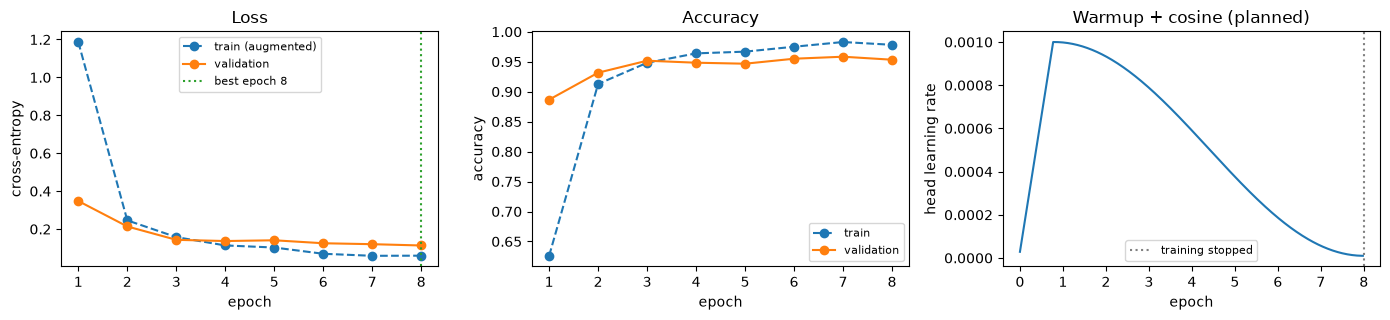

In [9]:
CKPT_DIR = OUT / "checkpoints"
seed_everything(CONFIG["seed"])
train_start = time.perf_counter()
history = fit(model, train_loader, val_loader, CONFIG, DEVICE, CKPT_DIR, amp_dtype=AMP_DTYPE)
TRAIN_SECONDS = time.perf_counter() - train_start
best_epoch = int(history.loc[history["val_loss"].idxmin(), "epoch"])
print(f"\ntrained {len(history)} epochs in {TRAIN_SECONDS:.0f} s | best epoch {best_epoch}: val loss {history['val_loss'].min():.4f}, "
      f"val acc {history.loc[best_epoch - 1, 'val_acc']:.3f}")

total_steps = CONFIG["epochs"] * len(train_loader)
planned = make_lr_lambda(total_steps, int(CONFIG["warmup_fraction"] * total_steps), CONFIG["min_lr_ratio"])
fig, axes = plt.subplots(1, 3, figsize=(14, 3.3))
axes[0].plot(history["epoch"], history["train_loss"], "o--", label="train (augmented)")
axes[0].plot(history["epoch"], history["val_loss"], "o-", label="validation")
axes[0].axvline(best_epoch, color="tab:green", ls=":", label=f"best epoch {best_epoch}")
axes[1].plot(history["epoch"], history["train_acc"], "o--", label="train")
axes[1].plot(history["epoch"], history["val_acc"], "o-", label="validation")
axes[2].plot(np.arange(total_steps) / len(train_loader), [CONFIG["lr"] * planned(s) for s in range(total_steps)])
axes[2].axvline(len(history), color="gray", ls=":", label="training stopped")
axes[0].set(xlabel="epoch", ylabel="cross-entropy", title="Loss")
axes[1].set(xlabel="epoch", ylabel="accuracy", title="Accuracy")
axes[2].set(xlabel="epoch", ylabel="head learning rate", title="Warmup + cosine (planned)")
for ax in axes:
    ax.legend(fontsize=8) if ax.get_legend_handles_labels()[0] else None
plt.tight_layout()
plt.show()

How to read the curves: validation loss **below** training loss is normal here, because training batches are augmented. Validation loss rising while training loss keeps falling = overfitting; early stopping has already kept the best epoch. A median gradient norm that suddenly jumps by orders of magnitude points to a too-high learning rate or bad data.

> 💡 **Interview angle:** "Walk me through your training loop." — zero grads, forward under autocast, loss in float32, backward (scaled for fp16), unscale then clip, optimizer step, scheduler step per batch; evaluate on validation each epoch, save best and last checkpoints, stop early. Then say *why* each piece is there.

## 8. Resume From a Checkpoint 🟡

Long runs crash: preempted cloud machines, out-of-memory, a laptop lid. Resuming correctly needs **more than the weights**: optimizer state (Adam's moving averages), scheduler position, `GradScaler` state, early-stopping counters, and random-number states (shuffle order, augmentation). `last.pt` stores all of them.

**Proof, not promise:** on the CPU with the small CNN and a few hundred images, we train 2 epochs straight through, then train 1 epoch, "crash", and resume for the 2nd. If resuming is correct, both runs end with **bit-identical weights**.

To resume a real run: `fit(model, train_loader, val_loader, CONFIG, DEVICE, CKPT_DIR, amp_dtype=AMP_DTYPE, resume_from=CKPT_DIR / "last.pt")`.

In [10]:
cpu = torch.device("cpu")
proof_config = {**CONFIG, "model_name": "small_cnn", "pretrained": False, "epochs": 2, "patience": 5}
proof_train = splits["train"].groupby("label_idx").head(32)
proof_val = splits["validation"].groupby("label_idx").head(8)


def proof_run(ckpt_dir, stop_after_epoch=None, resume=False):
    seed_everything(CONFIG["seed"])
    net = build_model("small_cnn", NUM_CLASSES, pretrained=False)
    loader = make_loader(proof_train, train_transform, shuffle=True, batch_size=32)
    fit(net, loader, make_loader(proof_val, eval_transform, shuffle=False), proof_config, cpu, ckpt_dir,
        resume_from=(Path(ckpt_dir) / "last.pt") if resume else None, stop_after_epoch=stop_after_epoch, log=lambda m: print("   ", m))
    return net


start = time.perf_counter()
print("A) two epochs without interruption")
straight = proof_run(OUT / "resume_proof" / "straight")
print("B) one epoch, crash, then resume")
proof_run(OUT / "resume_proof" / "interrupted", stop_after_epoch=1)
resumed = proof_run(OUT / "resume_proof" / "interrupted", resume=True)
identical = all(torch.equal(a, b) for a, b in zip(straight.state_dict().values(), resumed.state_dict().values()))
print(f"{'✅' if identical else '❌'} resumed weights {'are bit-identical to' if identical else 'differ from'} the uninterrupted run ({time.perf_counter() - start:.1f} s)")
assert identical

A) two epochs without interruption


    epoch 1: train loss 1.9189 acc 0.309 | val loss 2.1269 acc 0.213 | grad norm 2.59 | 0.6 s ← best


    epoch 2: train loss 1.5911 acc 0.444 | val loss 1.9867 acc 0.300 | grad norm 2.38 | 0.5 s ← best
B) one epoch, crash, then resume


    epoch 1: train loss 1.9189 acc 0.309 | val loss 2.1269 acc 0.213 | grad norm 2.59 | 0.5 s ← best
    (stopping after epoch 1 on purpose)
    resumed from _outputs/dl_template/resume_proof/interrupted/last.pt after epoch 1 (best val loss 2.1269)


    epoch 2: train loss 1.5911 acc 0.444 | val loss 1.9867 acc 0.300 | grad norm 2.38 | 0.5 s ← best
✅ resumed weights are bit-identical to the uninterrupted run (2.2 s)


> 💡 **Interview angle:** "Your resumed run diverges from the original. What did you forget to save?" — usually the optimizer state, the scheduler step, the `GradScaler`, or RNG/data-order state. Saving only `model.state_dict()` restarts Adam's statistics and the LR warmup.

## 9. Evaluation: Per-Class Metrics, Confusion Matrix, Calibration 🟡

First we load **`best.pt`**, the epoch early stopping chose. Evaluation runs in **full precision** even if training used mixed precision, because the exported model we ship runs in float32.

- **Temperature scaling** (fitted on the **validation** split): neural networks are often over-confident. One number $T$ softens (or sharpens) the probabilities: $\text{softmax}(z / T)$. Dividing all logits by the same number never changes the predicted class, so accuracy is unchanged.
- **ECE** (expected calibration error): the average gap between confidence and accuracy over confidence bins, reported before and after scaling.

Then the **test** split is scored **once**: accuracy and macro-F1 (every class counts equally) with 95% bootstrap confidence intervals, the per-class report, the confusion matrix, and the reliability diagram. The counter warns if you re-run it.

loaded best.pt from epoch 8 (val loss 0.1135)


temperature T = 1.102 (fitted on validation; T > 1 softens over-confident probabilities)


TEST accuracy: 0.9500 (95% CI 0.9300–0.9667)
TEST macro_f1: 0.9499 (95% CI 0.9299–0.9670)
TEST ECE: raw 0.0300 → temperature-scaled 0.0252 (improved) | majority-class accuracy 0.100

                      precision  recall  f1-score  support
AnnualCrop                0.937   0.983     0.959     60.0
Forest                    0.909   1.000     0.952     60.0
HerbaceousVegetation      0.981   0.850     0.911     60.0
Highway                   0.949   0.933     0.941     60.0
Industrial                1.000   0.933     0.966     60.0
Pasture                   1.000   0.933     0.966     60.0
PermanentCrop             0.879   0.967     0.921     60.0
Residential               0.923   1.000     0.960     60.0
River                     0.966   0.933     0.949     60.0
SeaLake                   0.983   0.967     0.975     60.0

weakest class by recall: HerbaceousVegetation (0.850)


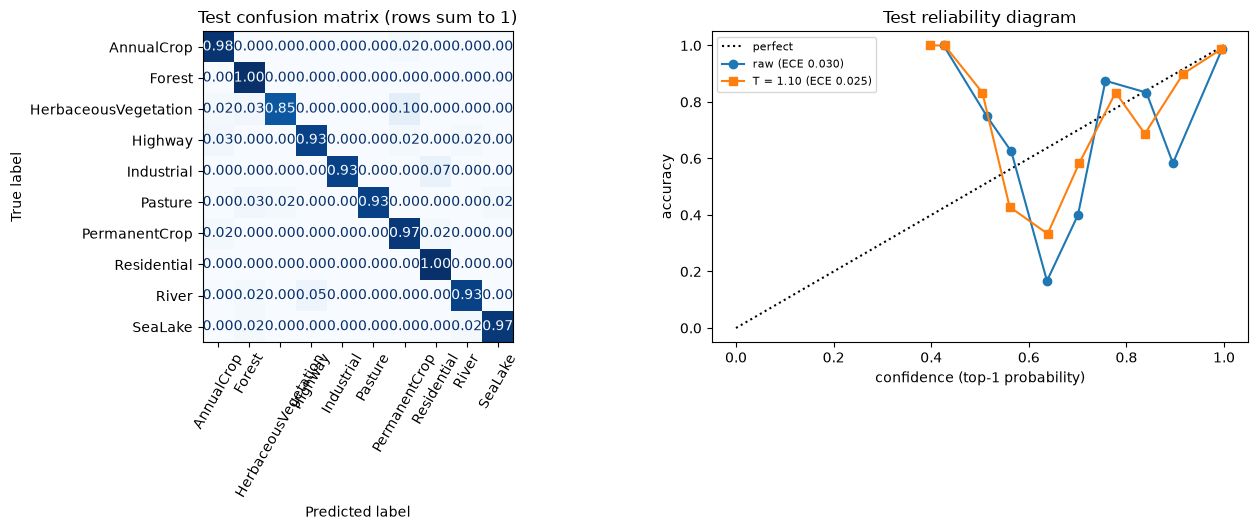

In [11]:
best = torch.load(CKPT_DIR / "best.pt", map_location=DEVICE, weights_only=True)
model.load_state_dict(best["model"])
print(f"loaded best.pt from epoch {best['epoch']} (val loss {best['val_loss']:.4f})")


def fit_temperature(logits: torch.Tensor, labels: torch.Tensor) -> float:
    log_t = torch.zeros(1, requires_grad=True)
    optimizer = torch.optim.LBFGS([log_t], lr=0.1, max_iter=100)

    def closure():
        optimizer.zero_grad()
        loss = F.cross_entropy(logits / log_t.exp(), labels)
        loss.backward()
        return loss

    optimizer.step(closure)
    return log_t.detach().exp().item()


def calibration_error(probs: np.ndarray, labels: np.ndarray, n_bins: int = 15):
    confidence, correct = probs.max(1), probs.argmax(1) == labels
    edges, ece, rows = np.linspace(0, 1, n_bins + 1), 0.0, []
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (confidence > lo) & (confidence <= hi)
        if mask.any():
            ece += mask.mean() * abs(correct[mask].mean() - confidence[mask].mean())
            rows.append({"confidence": confidence[mask].mean(), "accuracy": correct[mask].mean(), "n": int(mask.sum())})
    return float(ece), pd.DataFrame(rows)


val_logits, val_labels = predict_logits(model, val_loader, DEVICE)      # full precision: evaluate exactly what we ship (fp32 export)
TEMPERATURE = fit_temperature(val_logits, val_labels)
print(f"temperature T = {TEMPERATURE:.3f} (fitted on validation; T > 1 softens over-confident probabilities)")

TEST_EVALUATIONS = globals().get("TEST_EVALUATIONS", 0) + 1
if TEST_EVALUATIONS > 1:
    print(f"⚠️ The test set has been evaluated {TEST_EVALUATIONS} times this session: it is no longer an unbiased estimate.")
test_logits, test_labels = predict_logits(model, test_loader, DEVICE)     # 🔓 the only time the test split is scored
y_true, y_pred = test_labels.numpy(), test_logits.argmax(1).numpy()
probs_raw = torch.softmax(test_logits, 1).numpy()
probs_cal = torch.softmax(test_logits / TEMPERATURE, 1).numpy()
ece_raw, table_raw = calibration_error(probs_raw, y_true)
ece_cal, table_cal = calibration_error(probs_cal, y_true)

rng = np.random.default_rng(CONFIG["seed"])
boot = np.array([(lambda idx: ((y_true[idx] == y_pred[idx]).mean(), f1_score(y_true[idx], y_pred[idx], average="macro")))(rng.integers(0, len(y_true), len(y_true)))
                 for _ in range(1000)])
TEST_METRICS = {
    "accuracy": {"estimate": float((y_true == y_pred).mean()), "ci_low": float(np.percentile(boot[:, 0], 2.5)), "ci_high": float(np.percentile(boot[:, 0], 97.5))},
    "macro_f1": {"estimate": float(f1_score(y_true, y_pred, average="macro")), "ci_low": float(np.percentile(boot[:, 1], 2.5)), "ci_high": float(np.percentile(boot[:, 1], 97.5))},
    "ece_raw": ece_raw, "ece_calibrated": ece_cal, "n_test": int(len(y_true)),
}
for name in ("accuracy", "macro_f1"):
    m = TEST_METRICS[name]
    print(f"TEST {name}: {m['estimate']:.4f} (95% CI {m['ci_low']:.4f}–{m['ci_high']:.4f})")
print(f"TEST ECE: raw {ece_raw:.4f} → temperature-scaled {ece_cal:.4f} "
      f"({'improved' if ece_cal < ece_raw else 'not improved — T was fitted on a small validation split'}) | majority-class accuracy {counts.max() / counts.sum():.3f}")

per_class = pd.DataFrame(classification_report(y_true, y_pred, labels=range(NUM_CLASSES), target_names=CLASSES, output_dict=True, zero_division=0)).T.loc[CLASSES]
print("\n" + per_class.round(3).to_string())
print(f"\nweakest class by recall: {per_class['recall'].idxmin()} ({per_class['recall'].min():.3f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.4), gridspec_kw={"width_ratios": [1.35, 1]})
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, labels=range(NUM_CLASSES), display_labels=CLASSES, normalize="true", values_format=".2f",
                                        cmap="Blues", colorbar=False, ax=axes[0], xticks_rotation=60)
axes[0].set_title("Test confusion matrix (rows sum to 1)")
axes[1].plot([0, 1], [0, 1], "k:", label="perfect")
axes[1].plot(table_raw["confidence"], table_raw["accuracy"], "o-", label=f"raw (ECE {ece_raw:.3f})")
axes[1].plot(table_cal["confidence"], table_cal["accuracy"], "s-", label=f"T = {TEMPERATURE:.2f} (ECE {ece_cal:.3f})")
axes[1].set(xlabel="confidence (top-1 probability)", ylabel="accuracy", title="Test reliability diagram")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

> 💡 **Interview angle:** "Your classifier says 99% confident. Can you trust that?" — only if it's calibrated: check a reliability diagram and ECE on held-out data, fix over-confidence with temperature scaling fitted on validation, and report macro-F1 plus per-class recall so small classes can't hide.

## 10. Error Analysis 🟡

Metrics say *how often* the model fails; looking at failures says *why*. We do it on the **validation** split: anything you look at in order to decide what to change next (more data of one class, different augmentation, relabelling) must not come from the test set, or the next test score is biased.

Two views: the most frequent **confusion pairs**, and the **most confident mistakes** (the dangerous ones: they look certain). For each, ask: is the label wrong, is the image genuinely ambiguous, or is the model missing something learnable?

validation errors: 27 of 600 | top confusion pairs:
                true     predicted  count
HerbaceousVegetation PermanentCrop      7
               River       Highway      3
          AnnualCrop PermanentCrop      2
             Highway    Industrial      2
             Pasture        Forest      2
          AnnualCrop       SeaLake      1


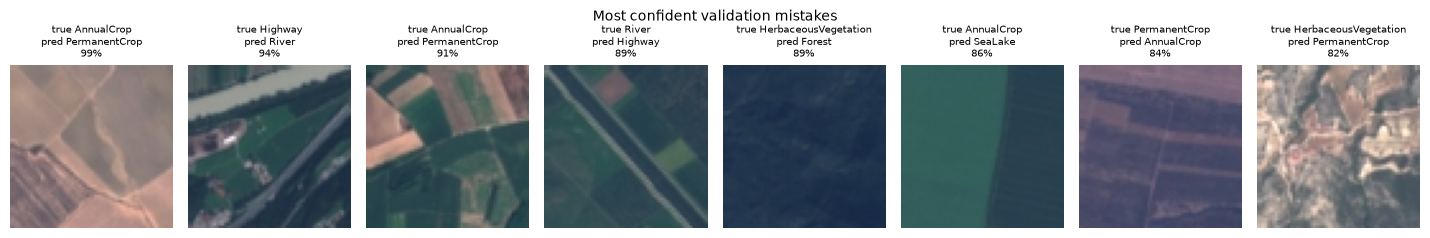

In [12]:
val_true, val_pred = val_labels.numpy(), val_logits.argmax(1).numpy()
val_probs = torch.softmax(val_logits / TEMPERATURE, 1).numpy()
val_frame = splits["validation"].reset_index(drop=True)
pairs = (pd.DataFrame({"true": [CLASSES[i] for i in val_true], "predicted": [CLASSES[i] for i in val_pred]})
         .query("true != predicted").value_counts().rename("count").reset_index())
print(f"validation errors: {(val_true != val_pred).sum()} of {len(val_true)} | top confusion pairs:")
print(pairs.head(6).to_string(index=False))

wrong = np.flatnonzero(val_true != val_pred)
confident_wrong = wrong[np.argsort(-val_probs[wrong].max(1))][:8]
if len(confident_wrong):
    fig, axes = plt.subplots(1, len(confident_wrong), figsize=(1.8 * len(confident_wrong), 2.5), squeeze=False)
    for ax, i in zip(axes[0], confident_wrong):
        ax.imshow(load_raw(val_frame.iloc[i]))
        ax.set_title(f"true {CLASSES[val_true[i]]}\npred {CLASSES[val_pred[i]]}\n{val_probs[i].max():.0%}", fontsize=7)
        ax.axis("off")
    plt.suptitle("Most confident validation mistakes", fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("no validation mistakes to show")

TODO(you): write down what you see (e.g. "River vs Highway: long thin structures; add rotation augmentation" or "3 of 8 look mislabelled; send to relabelling"), change **one** thing, retrain, and compare on validation. Grad-CAM heatmaps (see the capstone) help check *where* the model looks.

> 💡 **Interview angle:** "Accuracy is 95%. What would you do next?" — error analysis before bigger models: per-class recall, confusion pairs, confident mistakes, then fix the cause (labels, data coverage, augmentation) and re-measure on validation.

## 11. Export With `torch.export` 🟡

`torch.export.export` traces the model into an **ExportedProgram**: a graph of standard PyTorch operators plus the weights, saved as a `.pt2` file that loads **without your Python model classes**. It replaces TorchScript (deprecated). We mark the batch dimension as **dynamic** so one file serves batch 1 and batch 256.

**The device rule:** the example input must be on the **same device** as the model. A model on `mps`/`cuda` with an example tensor on the CPU fails with a device-mismatch error (the old template hid this behind "export failed"). We export an eval-mode copy on the device we'll **serve** on (CPU by default), create the example input on that model's device, and check the exported program matches the eager model.

In [13]:
if DEVICE.type != "cpu":
    batch_dim = torch.export.Dim("batch", min=1, max=1024)
    try:                                                                    # ❌ the classic mistake, shown honestly
        torch.export.export(model.eval(), (torch.rand(2, 3, SIZE, SIZE),), dynamic_shapes={"x": {0: batch_dim}})
        print("export with a CPU example and a GPU model unexpectedly worked")
    except Exception as error:
        print(f"❌ model on {DEVICE.type}, example on cpu → {type(error).__name__}: {str(error).splitlines()[0][:160]}")
else:
    print("⏭️ Skipped the device-mismatch demo: this machine trains on the CPU, so model and example already share a device.")

SERVE_DEVICE = torch.device("cpu")                                          # TODO(you): "cuda" if you serve on a GPU
ARTIFACTS = OUT / "artifacts"
export_model = copy.deepcopy(model).to(SERVE_DEVICE).eval()
example_input = torch.rand(2, 3, SIZE, SIZE, device=next(export_model.parameters()).device)   # ✅ same device as the model
start = time.perf_counter()
exported = torch.export.export(export_model, (example_input,), dynamic_shapes={"x": {0: torch.export.Dim("batch", min=1, max=1024)}})
torch.export.save(exported, ARTIFACTS / "model.pt2")
program = torch.export.load(ARTIFACTS / "model.pt2").module()
print(f"✅ exported on {SERVE_DEVICE.type}, saved and reloaded in {time.perf_counter() - start:.1f} s → {rel(ARTIFACTS / 'model.pt2')} "
      f"({(ARTIFACTS / 'model.pt2').stat().st_size / 1e6:.1f} MB)")

check_images = torch.cat([x for x, _ in [next(iter(val_loader))]])[:32]
with torch.inference_mode():
    for batch_size in (1, 7, 32):
        x = check_images[:batch_size].to(SERVE_DEVICE)
        diff = (program(x) - export_model(x)).abs().max().item()
        print(f"batch {batch_size:2d}: max |exported − eager| = {diff:.1e}")
        assert diff < 1e-4

missing = [pkg for pkg in ("onnx", "onnxscript") if importlib.util.find_spec(pkg) is None]
if missing:
    print(f"⏭️ Skipped ONNX export: {' and '.join(missing)} not installed (torch.onnx's exporter needs onnx and onnxscript). "
          "To enable: pip install onnx onnxscript onnxruntime")
else:
    onnx_program = torch.onnx.export(export_model, (example_input,), dynamo=True, dynamic_shapes={"x": {0: torch.export.Dim("batch", min=1, max=1024)}})
    onnx_program.save(ARTIFACTS / "model.onnx")
    print("✅ ONNX export saved to", rel(ARTIFACTS / "model.onnx"))

❌ model on mps, example on cpu → RuntimeError: Tensor on device mps:0 is not on the expected device cpu!


✅ exported on cpu, saved and reloaded in 0.3 s → _outputs/dl_template/artifacts/model.pt2 (45.1 MB)
batch  1: max |exported − eager| = 0.0e+00
batch  7: max |exported − eager| = 0.0e+00


batch 32: max |exported − eager| = 0.0e+00


[torch.onnx] Obtain model graph for `ImageModel([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ImageModel([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
✅ ONNX export saved to _outputs/dl_template/artifacts/model.onnx


> 💡 **Interview angle:** "The exported model disagrees with the notebook model." — check it was exported in `eval()` mode (BatchNorm/Dropout), the example input's device, dtype and value range, dynamic shapes, and matching PyTorch versions; then test parity on several batch sizes, as above.

## 12. An Inference Function 🟢

Serving code should depend only on **files** (`model.pt2` + `metadata.json`), never on the training notebook. `Predictor` takes raw images (PIL images, file paths, or uint8 tensors), applies the **same** `make_eval_transform`, runs the exported program, applies the temperature, and returns the top-k classes with probabilities.

Here we build it from objects in memory; Step 13 saves the metadata and loads a `Predictor` purely from disk.

In [14]:
class Predictor:
    def __init__(self, program, classes: list[str], temperature: float, image_size: int, device=torch.device("cpu")):
        self.program, self.classes, self.temperature, self.device = program, classes, temperature, device
        self.transform = make_eval_transform(image_size)

    @classmethod
    def load(cls, directory, device=torch.device("cpu")):
        directory = Path(directory)
        meta = json.loads((directory / "metadata.json").read_text())
        return cls(torch.export.load(directory / "model.pt2").module(), meta["classes"], meta["temperature"], meta["image_size"], device)

    def _to_tensor(self, image):
        if isinstance(image, (str, Path)):
            with Image.open(image) as handle:
                image = handle.convert("RGB")
        return self.transform(image)

    def predict_proba(self, images) -> torch.Tensor:
        batch = torch.stack([self._to_tensor(image) for image in images]).to(self.device)
        with torch.inference_mode():
            return torch.softmax(self.program(batch).float() / self.temperature, dim=1).cpu()

    def predict(self, images, k: int = 3) -> list[dict]:
        probs = self.predict_proba(images)
        top = probs.topk(min(k, len(self.classes)), dim=1)
        return [{"label": self.classes[int(idx[0])], "confidence": round(float(p[0]), 4),
                 "top_k": [(self.classes[int(j)], round(float(q), 4)) for q, j in zip(p, idx)]} for p, idx in zip(top.values, top.indices)]


predictor = Predictor(program, CLASSES, TEMPERATURE, SIZE)
demo_rows = splits["validation"].groupby("label_idx").head(1).head(5)
demo_images = [load_raw(row) for _, row in demo_rows.iterrows()]
for (_, row), result in zip(demo_rows.iterrows(), predictor.predict(demo_images)):
    print(f"true {row['label']:22s} → {result['label']:22s} {result['confidence']:.1%} | top-3 {result['top_k']}")

true AnnualCrop             → PermanentCrop          90.9% | top-3 [('PermanentCrop', 0.9091), ('AnnualCrop', 0.0806), ('River', 0.0076)]
true Forest                 → Forest                 99.9% | top-3 [('Forest', 0.999), ('HerbaceousVegetation', 0.0007), ('Pasture', 0.0001)]
true HerbaceousVegetation   → HerbaceousVegetation   100.0% | top-3 [('HerbaceousVegetation', 0.9999), ('River', 0.0), ('PermanentCrop', 0.0)]
true Highway                → Highway                100.0% | top-3 [('Highway', 0.9998), ('River', 0.0002), ('Pasture', 0.0)]
true Industrial             → Industrial             99.9% | top-3 [('Industrial', 0.9991), ('Residential', 0.0005), ('Highway', 0.0001)]


## 13. Save Metadata 🟢

`metadata.json` makes the artifact **self-describing**: what it predicts (classes, input format), how it was made (config, data split hashes, device, AMP decision, training history), how good it is (test metrics with CIs, per-class metrics), and what serving needs (temperature, image size, export file hash, PyTorch version). The version is `model_version+fingerprint` of the weights, so different weights can never share a version.

Finally we load a `Predictor` **from disk only** and check it reproduces the evaluated test predictions.

In [15]:
digest = hashlib.sha256()
for name, tensor in sorted(export_model.state_dict().items()):
    digest.update(name.encode())
    digest.update(tensor.detach().cpu().contiguous().numpy().tobytes())

metadata = {
    "model_name": CONFIG["project_name"],
    "model_version": f"{CONFIG['model_version']}+{digest.hexdigest()[:8]}",
    "created_at": datetime.now(UTC).isoformat(timespec="seconds"),
    "classes": CLASSES,
    "architecture": f"{CONFIG['model_name']} (pretrained={CONFIG['pretrained']}), input resized to {CONFIG['model_input_size'] if CONFIG['model_name'] == 'resnet18' else SIZE} px inside the model",
    "input": {"format": "float32 RGB in [0, 1], shape (batch, 3, H, W)", "image_size": SIZE, "normalization": "inside the model"},
    "image_size": SIZE,
    "temperature": TEMPERATURE,
    "export": {"file": "model.pt2", "format": "torch.export ExportedProgram", "device": SERVE_DEVICE.type, "dynamic_batch": [1, 1024],
               "sha256": file_sha256(ARTIFACTS / "model.pt2"), "onnx": "skipped: " + ", ".join(missing) + " missing" if missing else "model.onnx"},
    "training": {"device": DEVICE.type, "mixed_precision": AMP_NOTE, "epochs_run": len(history), "best_epoch": int(best["epoch"]),
                 "seconds": round(TRAIN_SECONDS, 1), "history": history.round(5).to_dict(orient="records")},
    "data": {"source": CONFIG["data_source"], "n_examples": len(samples),
             "splits": {name: {"rows": len(frame), "sha256": SPLIT_HASHES[name]} for name, frame in splits.items()}},
    "test_metrics": TEST_METRICS,
    "per_class_test_metrics": per_class.round(4).to_dict(orient="index"),
    "config": {k: str(v) for k, v in CONFIG.items()},
    "versions": {"python": platform.python_version(), "torch": torch.__version__, "torchvision": torchvision.__version__},
}
(ARTIFACTS / "metadata.json").write_text(json.dumps(metadata, indent=2))
for path in sorted(ARTIFACTS.iterdir()):
    print(f"{rel(path):45s} {path.stat().st_size / 1e6:8.2f} MB")
print(json.dumps({k: metadata[k] for k in ["model_version", "architecture", "temperature"]}, indent=1))

loaded = Predictor.load(ARTIFACTS)
n_check = min(128, len(splits["test"]))
disk_probs = loaded.predict_proba([load_raw(row) for _, row in splits["test"].head(n_check).iterrows()])
agreement = (disk_probs.argmax(1).numpy() == y_pred[:n_check]).mean()
max_diff = np.abs(disk_probs.numpy() - probs_cal[:n_check]).max()
print(f"Predictor.load (CPU, from disk) vs evaluated model ({DEVICE.type}) on {n_check} test images: top-1 agreement {agreement:.2%}, max probability difference {max_diff:.1e}")
assert agreement == 1.0 and max_diff < 1e-3, f"reloaded bundle disagrees: agreement {agreement:.4f}, max diff {max_diff:.2e}"
print(f"✅ artifact bundle verified | whole notebook ran in {(time.perf_counter() - NOTEBOOK_START) / 60:.1f} min")
free_memory()

_outputs/dl_template/artifacts/metadata.json      0.01 MB
_outputs/dl_template/artifacts/model.onnx        44.82 MB
_outputs/dl_template/artifacts/model.pt2         45.13 MB
{
 "model_version": "0.1.0+8241f1a7",
 "architecture": "resnet18 (pretrained=True), input resized to 112 px inside the model",
 "temperature": 1.1018686294555664
}


Predictor.load (CPU, from disk) vs evaluated model (mps) on 128 test images: top-1 agreement 100.00%, max probability difference 7.0e-06
✅ artifact bundle verified | whole notebook ran in 0.5 min


## ✅ Checklist

Tick every box before anyone relies on the model. Unticked boxes go into the model card as known limitations.

**Data**
- [ ] Labels were spot-checked by a person (look at 20 random images per class).
- [ ] Splits are saved, stratified, and free of **group leakage** (same object/patient/location in one split only).
- [ ] Duplicate and near-duplicate images across splits were checked.
- [ ] Augmentations keep every label true for this domain.

**Training**
- [ ] A simple baseline (small CNN or frozen backbone) was trained first; the final model clearly beats it.
- [ ] Training curves were read: no divergence, no exploding gradient norms, early stopping kept the best epoch.
- [ ] Mixed precision was measured, not assumed; results match full precision.
- [ ] Resuming from `last.pt` was tested.

**Evaluation**
- [ ] Test set evaluated **once**, from `best.pt`; accuracy and macro-F1 have confidence intervals.
- [ ] Per-class recall meets the requirement for **every** class, not just on average.
- [ ] Calibration checked; temperature fitted on validation and saved.
- [ ] Error analysis done on validation; findings written down.

**Shipping**
- [ ] Exported with `torch.export` from an `eval()` copy; example input on the model's device; parity checked on several batch sizes.
- [ ] Inference loads only `model.pt2` + `metadata.json` and uses the same eval transform as training.
- [ ] Metadata has version, classes, temperature, split hashes, metrics, and library versions.
- [ ] Latency measured on the serving hardware at the real batch size (p50/p95, including preprocessing).
- [ ] Monitoring plan: input drift (brightness, size, source), confidence distribution, human-review rate.

## 📚 Resources

### 📖 Official Docs
- [PyTorch — torch.export](https://docs.pytorch.org/docs/2.14/user_guide/torch_compiler/export.html) — ExportedProgram, dynamic shapes, saving and loading
- [PyTorch — Automatic Mixed Precision package - torch.amp](https://docs.pytorch.org/docs/2.14/amp.html) — autocast, GradScaler, and which ops run in half precision
- [PyTorch — Saving and Loading Models](https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html) — checkpoints for resuming training
- [torchvision — Transforming images, videos, boxes and more](https://docs.pytorch.org/vision/stable/transforms.html) — the `transforms.v2` API used in Step 4
- [torchvision — Models and pre-trained weights](https://docs.pytorch.org/vision/stable/models.html) — backbones and their weights enums

### 🎥 Videos
- [3Blue1Brown — But what is a convolution?](https://www.youtube.com/watch?v=KuXjwB4LzSA) (~23 min) — visual intuition for the layers inside every CNN here

### 📄 Papers
- [Guo et al. (2017) — On Calibration of Modern Neural Networks](https://arxiv.org/abs/1706.04599) — over-confidence and temperature scaling
- [He et al. (2015) — Deep Residual Learning for Image Recognition](https://arxiv.org/abs/1512.03385) — ResNet, the default backbone
- [Helber et al. (2019) — EuroSAT: A Novel Dataset and Deep Learning Benchmark for Land Use and Land Cover Classification](https://arxiv.org/abs/1709.00029) — the example dataset

### 📘 Books & Worked Examples
- [End-to-End DL Project (this course)](../13_Capstone_Projects/02_End_to_End_DL_Project.ipynb) — this template filled in: Grad-CAM, latency, upload API, Docker, CI
- [Andrej Karpathy — A Recipe for Training Neural Networks](http://karpathy.github.io/2019/04/25/recipe/) — the debugging-first workflow behind this template
- [Dive into Deep Learning — Fine-Tuning](https://d2l.ai/chapter_computer-vision/fine-tuning.html) — free chapter on transfer learning with code

## ➡️ What's Next

**[03 · LLM Template](03_LLM_Template.ipynb)** — the same copy-and-fill discipline for LLM applications: prompts and configs in one place, evaluation sets, and honest, repeatable measurement.